<a href="https://colab.research.google.com/github/prqshna-design/ML-mini-project-tasks/blob/main/Taxi_Fare_Prediction_Using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn import linear_model, metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# 1. Create manual dataset
data = {
    "Distance": [
        1.0, 1.5, 2.0, 2.5, 3.0,
        3.5, 4.0, 4.5, 5.0, 5.5,
        6.0, 6.5, 7.0, 7.5, 8.0,
        8.5, 9.0, 9.5, 10.0, 11.0,
        12.0, 13.0, 14.0, 15.0, 16.0,
        17.0, 18.0, 19.0, 20.0, 22.0
    ],

    "Trip_Duration": [
        10, 15, 20, 25, 30,
        35, 40, 45, 50, 55,
        60, 65, 70, 75, 80,
        85, 90, 95, 100, 110,
        120, 130, 140, 150, 160,
        170, 180, 190, 200, 220
    ],

    "Passengers": [
        1, 1, 2, 1, 2,
        3, 1, 2, 1, 2,
        3, 1, 2, 3, 1,
        2, 4, 1, 2, 3,
        1, 2, 1, 3, 2,
        1, 4, 2, 3, 1
    ],

    "Time_of_Day": [
        7, 8, 9, 10, 11,
        12, 13, 14, 15, 16,
        17, 18, 19, 20, 21,
        22, 23, 6, 7, 8,
        9, 10, 11, 12, 13,
        14, 15, 16, 17, 18
    ],

    "Fare": [
        8, 10, 12, 15, 17,
        20, 22, 25, 27, 30,
        32, 35, 37, 40, 43,
        46, 48, 51, 54, 58,
        62, 66, 70, 75, 80,
        85, 90, 95, 100, 110
    ]
}

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209673 entries, 0 to 209672
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   trip_duration      209673 non-null  int64  
 1   distance_traveled  209673 non-null  float64
 2   num_of_passengers  209673 non-null  int64  
 3   fare               209673 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 6.4 MB


In [ ]:

# 2. Clean dataset
print("Missing values:")
print(df.isnull().sum())


,trip_duration,distance_traveled,num_of_passengers,fare
count,209673.000000,209673.000000,209673.000000,209673.000000
mean,1173.181478,5.054431,1.292808,99.623431
std,4775.653621,125.217419,0.930754,85.602702
min,0.000000,0.020000,0.000000,0.000000
25%,446.000000,1.950000,1.000000,52.500000
50%,707.000000,3.200000,1.000000,75.000000
75%,1098.000000,5.730000,1.000000,116.250000
max,86387.000000,57283.910000,9.000000,4466.250000


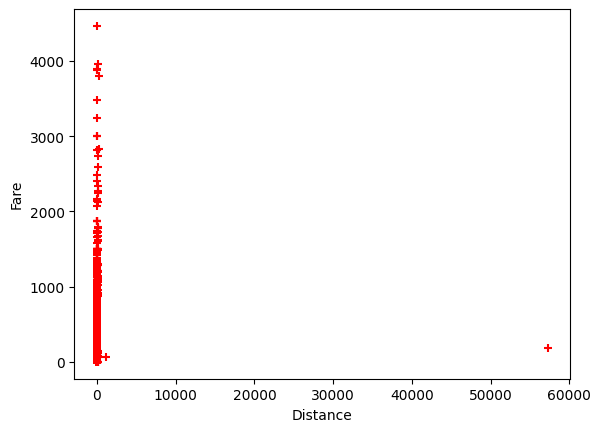

In [ ]:

# 3. Handle outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (
    (df < (Q1 - 0.4 * IQR)) |
    (df > (Q3 + 0.4 * IQR))
)

df = df[~outlier_mask.any(axis=1)]

In [ ]:
# 4. Train-Test Split
X = df[
    ["Distance", "Trip_Duration", "Passengers", "Time_of_Day"]
]

y = df["Fare"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

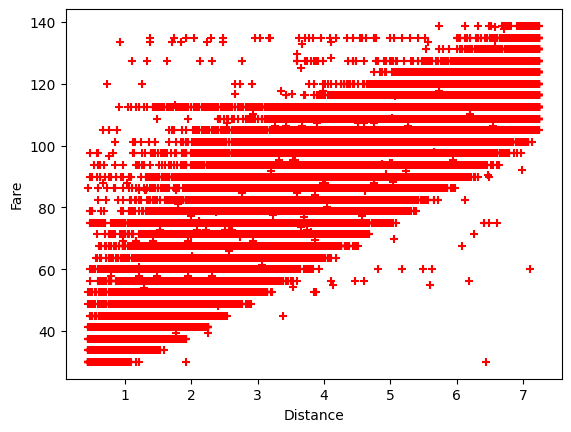

In [ ]:


# 5. Build Linear Regression Model
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

In [ ]:

# 6. Predict
y_pred = model.predict(X_test)

,trip_duration,distance_traveled,num_of_passengers,fare
count,130502.000000,130502.000000,130502.0,130502.000000
mean,642.129868,2.981605,1.0,69.799260
std,278.443475,1.472674,0.0,23.225543
min,186.000000,0.450000,1.0,30.000000
25%,420.000000,1.850000,1.0,52.500000
50%,604.000000,2.670000,1.0,67.500000
75%,830.000000,3.880000,1.0,86.250000
max,1358.000000,7.240000,1.0,138.750000


In [ ]:
# 7. Evaluate Model
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

In [ ]:
# 8. Analyze Residuals
residuals = y_test - y_pred
+
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.show()



LinearRegression()

In [ ]:
# 9. Compare Actual vs Predicted Fare
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()

Mean Squared Error (MSE): 21.334656790470067
Root Mean Squared Error (RMSE): 4.618945419732741
R-squared (R2): 0.9604711609824237


In [ ]:
#Predicting the own data
duration = 50
distance = 17
passanger = 2
model.predict([[duration,distance,passanger]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[151.98541176]])